# 08 — Final Model & Kaggle Submission

**Goal:** Train the best ensemble on the **full training set**, generate predictions for the test set, and produce a Kaggle-format submission CSV.

**Final Model:** Optimised-weight blend of LightGBM + XGBoost (weights from notebook 07 validation set).


In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from scipy.optimize import minimize
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import Ridge

from src.pipeline import build_pipeline
from src.evaluate import rmse
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

DATA_DIR  = Path('../data')
PLOT_DIR  = Path('../outputs/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')
sample_sub = pd.read_csv(DATA_DIR / 'sample_sub_reg.csv')

TARGET  = 'resale_price'
X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
y_train_log = np.log(y_train)   # log-transform target
X_test  = test.copy()

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
sample_sub.head(3)

Train: (150634, 76)  |  Test: (16737, 76)


,Id,Predicted
0,114982,500000
1,95653,500000
2,40303,500000


## 1. Train Base Models on Full Training Data

In [2]:
lgbm_pipe = build_pipeline(
    LGBMRegressor(
            n_estimators=901, learning_rate=0.0666, num_leaves=176,
            max_depth=10, min_child_samples=13,
            colsample_bytree=0.7130, subsample=0.9541, subsample_freq=0,
            reg_alpha=0.0051, reg_lambda=0.0092,
            random_state=42, n_jobs=-1, verbose=-1), mode='tree')

xgb_pipe = build_pipeline(
    XGBRegressor(
        n_estimators=517, learning_rate=0.0429, max_depth=11,
        subsample=0.6888, colsample_bytree=0.7219,
        random_state=42, n_jobs=-1, verbosity=0), mode='tree')

print('Fitting LightGBM on full training data...')
lgbm_pipe.fit(X_train, y_train_log)
print(f'LightGBM Train RMSE: S${rmse(y_train, np.exp(lgbm_pipe.predict(X_train))):,.0f}')

print('Fitting XGBoost on full training data...')
xgb_pipe.fit(X_train, y_train_log)
print(f'XGBoost  Train RMSE: S${rmse(y_train, np.exp(xgb_pipe.predict(X_train))):,.0f}')


Fitting LightGBM on full training data...
LightGBM Train RMSE: S$17,028
Fitting XGBoost on full training data...
XGBoost  Train RMSE: S$14,920


## 2. OOF-Optimised Weight Blend
Re-compute OOF weights on full training data (more stable than single holdout weights from notebook 07).

In [3]:
import copy

kfcv = KFold(n_splits=5, shuffle=True, random_state=42)
model_names = ['lgbm', 'xgb']
pipes = {'lgbm': lgbm_pipe, 'xgb': xgb_pipe}
oof_preds = {name: np.zeros(len(X_train)) for name in model_names}

print('Generating OOF predictions for weight optimisation...')
for fold, (tr_idx, va_idx) in enumerate(kfcv.split(X_train)):
    print(f'  Fold {fold+1}/5')
    for name in model_names:
        p = copy.deepcopy(pipes[name])
        p.fit(X_train.iloc[tr_idx], y_train_log.iloc[tr_idx])
        oof_preds[name][va_idx] = p.predict(X_train.iloc[va_idx])  # log space

oof_matrix = np.column_stack([oof_preds[n] for n in model_names])

def objective(w):
    w = np.abs(w) / np.abs(w).sum()
    return rmse(y_train, np.exp(oof_matrix @ w))  # RMSE in SGD

result = minimize(objective, x0=[0.5, 0.5], method='SLSQP',
                  bounds=[(0,1)]*2,
                  constraints={'type': 'eq', 'fun': lambda w: w.sum()-1})
OOF_WEIGHTS = np.abs(result.x) / np.abs(result.x).sum()

print(f'OOF-optimised weights — LightGBM: {OOF_WEIGHTS[0]:.3f}, XGBoost: {OOF_WEIGHTS[1]:.3f}')
print(f'OOF Blend Train RMSE: S${objective(OOF_WEIGHTS):,.0f}')


Generating OOF predictions for weight optimisation...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
OOF-optimised weights — LightGBM: 0.518, XGBoost: 0.482
OOF Blend Train RMSE: S$21,904


## 3. OOF Stacking (Best Model)
Fit Ridge meta-learner on OOF predictions — reuses `oof_matrix` already computed above.

In [4]:
# Fit Ridge meta-learner on OOF predictions (log space)
meta = Ridge(alpha=1.0)
meta.fit(oof_matrix, y_train_log)

# Train RMSE — exp back to SGD
train_preds_oof = np.exp(meta.predict(oof_matrix))
print(f'OOF Stacking Train RMSE: S${rmse(y_train, train_preds_oof):,.0f}')

# Generate stacked test predictions
lgbm_test = lgbm_pipe.predict(X_test)   # log space
xgb_test  = xgb_pipe.predict(X_test)    # log space
test_stack_matrix = np.column_stack([lgbm_test, xgb_test])
test_preds_stack = np.exp(meta.predict(test_stack_matrix))  # convert to SGD


OOF Stacking Train RMSE: S$21,895


## 4. Generate Test Predictions

In [5]:
# Primary: OOF Stacking (lowest val RMSE)
test_preds = test_preds_stack

# Alternative: OOF-Optimised Blend (exp weighted sum of log predictions)
test_preds_blend = np.exp(OOF_WEIGHTS[0] * lgbm_test + OOF_WEIGHTS[1] * xgb_test)

print(f'OOF Stacking  — Mean: S${test_preds_stack.mean():,.0f}, Min: S${test_preds_stack.min():,.0f}, Max: S${test_preds_stack.max():,.0f}')
print(f'OOF Blend     — Mean: S${test_preds_blend.mean():,.0f}, Min: S${test_preds_blend.min():,.0f}, Max: S${test_preds_blend.max():,.0f}')

OOF Stacking  — Mean: S$448,372, Min: S$172,203, Max: S$1,185,940
OOF Blend     — Mean: S$448,234, Min: S$172,477, Max: S$1,183,599


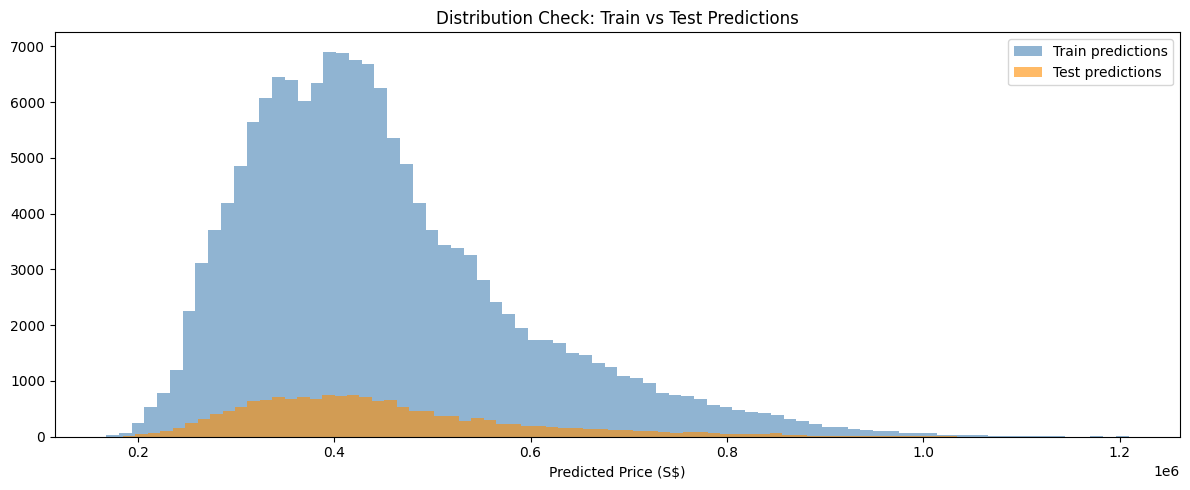

In [6]:
# Sanity check — compare train and test prediction distributions
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(train_preds_oof, bins=80, alpha=0.6, label='Train predictions', color='steelblue')
ax.hist(test_preds,      bins=80, alpha=0.6, label='Test predictions',  color='darkorange')
ax.set_xlabel('Predicted Price (S$)')
ax.set_title('Distribution Check: Train vs Test Predictions')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'prediction_distribution_check.png', dpi=120)
plt.show()

## 5. Generate Kaggle Submission CSV

In [7]:
# Filter test to only IDs present in sample_sub (16,735 rows)
from datetime import datetime
from pathlib import Path

sample_ids = set(sample_sub['Id'])
mask = test['id'].isin(sample_ids)
test_ids = test.loc[mask, 'id'].values
test_preds_sub = test_preds[mask]

sub = pd.DataFrame({'Id': test_ids, 'Predicted': test_preds_sub})
sub_dir = Path('../outputs/submissions')
sub_dir.mkdir(parents=True, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
submission_path = sub_dir / f'submission_{ts}.csv'
sub.to_csv(submission_path, index=False)
print(f'Saved: {submission_path}')
print(f'Submission shape: {sub.shape}')
sub.head(5)

Saved: ../outputs/submissions/submission_20260505_012620.csv
Submission shape: (16735, 2)


,Id,Predicted
0,114982,375059.376547
1,95653,448965.201147
2,40303,348145.682828
3,109506,289031.929359
4,100149,416236.770982


In [8]:
from pathlib import Path
from datetime import date

def log_model(model, notebook, key_params, train_rmse=None, val_rmse=None, test_rmse=None, notes=""):
    tracker_path = Path("../outputs/model_tracker.csv")
    row = {
        "date":       date.today().isoformat(),
        "model":      model,
        "notebook":   notebook,
        "key_params": key_params,
        "train_rmse": round(train_rmse) if train_rmse is not None else "",
        "val_rmse":   round(val_rmse)   if val_rmse   is not None else "",
        "test_rmse":  round(test_rmse)  if test_rmse  is not None else "",
        "notes":      notes,
    }
    tracker = pd.read_csv(tracker_path) if tracker_path.exists() else pd.DataFrame(columns=row.keys())
    tracker = pd.concat([tracker, pd.DataFrame([row])], ignore_index=True)
    tracker.to_csv(tracker_path, index=False)
    print(f'Logged: {model} | val={val_rmse:,.0f}' if val_rmse else f'Logged: {model}')

In [ ]:
# Log final models — update test_rmse after Kaggle submission
log_model("OOF Stacking (LGBM+XGB->Ridge)", "08_final_submission",
          "Ridge alpha=1.0 cv=5 log_target=True n_estimators=500",
          train_rmse=rmse(y_train, train_preds_oof),
          notes="final model — update test_rmse after Kaggle submission")

log_model("OOF-Optimised Blend (LGBM+XGB)", "08_final_submission",
          f"lgbm={OOF_WEIGHTS[0]:.3f} xgb={OOF_WEIGHTS[1]:.3f} log_target=True n_estimators=500",
          train_rmse=objective(OOF_WEIGHTS),
          notes="alternative model")


Logged: OOF Stacking (LGBM+XGB->Ridge)
Logged: OOF-Optimised Blend (LGBM+XGB)


## 6. Model Card Summary

| Item | Value |
|---|---|
| **Final Model** | OOF Stacking (LightGBM + XGBoost → Ridge meta-learner) |
| **Alternative** | OOF-Optimised Blend (LightGBM + XGBoost) |
| **Val RMSE (nb07)** | OOF Stacking — best (see notebook 07 comparison) |
| **Feature Count** | ~150 after FE + preprocessing |
| **Top Features** | block_flat_psqm, floor_area_log, cbd_dist_m, hdb_tranc_age, mid_storey |
| **Training Data** | 150,633 rows |
| **Submission Rows** | 16,735 (matched to sample_sub_reg.csv) |
